# 01 — Data Collection & Diagnostic
**Project:** KPI Operations Pipeline · **Stage 1 of 3**

O objetivo desta etapa é carregar o dataset bruto e entender o que temos **antes de modificar qualquer coisa**.

> Regra de ouro em análise de dados: nunca transforme o que você ainda não inspecionou.


## 1. Imports

In [1]:
import pandas as pd           # manipulação de tabelas (DataFrames)
import numpy as np            # operações numéricas
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("muted")
print("Imports OK")

Imports OK


## 2. Caminhos dos arquivos

In [2]:
# Path.cwd() = pasta atual onde o notebook está rodando
# .parent sobe um nível: notebooks/ → raiz do projeto

PROJECT_ROOT = Path.cwd().parent
RAW_PATH     = PROJECT_ROOT / "data" / "raw" / "customer_support_tickets.csv"

print(f"Raiz do projeto : {PROJECT_ROOT}")
print(f"Arquivo buscado : {RAW_PATH}")
print(f"Existe?         : {RAW_PATH.exists()}")

Raiz do projeto : c:\Users\arthu\%USERPROFILE%\Documents\GitHub\kpi-operations-pipeline
Arquivo buscado : c:\Users\arthu\%USERPROFILE%\Documents\GitHub\kpi-operations-pipeline\data\raw\customer_support_tickets.csv
Existe?         : True


## 3. Carregar o dataset

In [3]:
# Se aparecer FileNotFoundError:
#   → Confirme que o CSV está em data/raw/customer_support_tickets.csv
#   → Download: kaggle.com/datasets/suraj520/customer-support-ticket-dataset

df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df.head()

Shape: 8,469 linhas × 17 colunas


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 4. Nomes e tipos das colunas

In [4]:
# dtype 'object' = texto (string)
# dtype 'int64'  = número inteiro
# dtype 'float64'= número decimal
# Colunas de data geralmente chegam como 'object' — vamos corrigir isso no notebook 02

print("Colunas e tipos:")
print("-" * 40)
for col, dtype in df.dtypes.items():
    print(f"  {col:<40} {str(dtype)}")

Colunas e tipos:
----------------------------------------
  Ticket ID                                int64
  Customer Name                            object
  Customer Email                           object
  Customer Age                             int64
  Customer Gender                          object
  Product Purchased                        object
  Date of Purchase                         object
  Ticket Type                              object
  Ticket Subject                           object
  Ticket Description                       object
  Ticket Status                            object
  Resolution                               object
  Ticket Priority                          object
  Ticket Channel                           object
  First Response Time                      object
  Time to Resolution                       object
  Customer Satisfaction Rating             float64


## 5. Valores ausentes (nulos)

In [5]:
null_counts = df.isnull().sum()
null_pct    = (df.isnull().mean() * 100).round(2)

null_report = (pd.DataFrame({"nulos": null_counts, "pct_%": null_pct})
                 .query("nulos > 0")
                 .sort_values("pct_%", ascending=False))

if null_report.empty:
    print("Nenhum valor nulo encontrado.")
else:
    print(f"Colunas com nulos ({len(null_report)} encontradas):")
    print(null_report.to_string())

Colunas com nulos (4 encontradas):
                              nulos  pct_%
Resolution                     5700  67.30
Time to Resolution             5700  67.30
Customer Satisfaction Rating   5700  67.30
First Response Time            2819  33.29


## 6. Estatísticas básicas

In [6]:
# count  = linhas não-nulas
# mean   = média
# std    = desvio padrão (quanto os valores variam)
# min/max = menor/maior valor
# 50%    = mediana (metade dos dados está abaixo disso)
df.describe().round(2)

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.00,8469.00,2769.00
mean,4235.00,44.03,2.99
std,2444.93,15.30,1.41
min,1.00,18.00,1.00
25%,2118.00,31.00,2.00
50%,4235.00,44.00,3.00
75%,6352.00,57.00,4.00
max,8469.00,70.00,5.00


## 7. Distribuição do CSAT (satisfação do cliente)

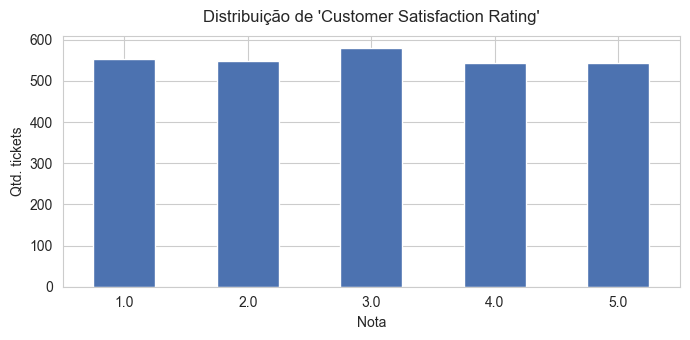

Contagem por nota:
Customer Satisfaction Rating
1.0    553
2.0    549
3.0    580
4.0    543
5.0    544


In [7]:
csat_col = next((c for c in df.columns if "satisfaction" in c.lower() or "rating" in c.lower()), None)

if csat_col:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    df[csat_col].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Distribuição de '{csat_col}'", fontsize=12, pad=10)
    ax.set_xlabel("Nota")
    ax.set_ylabel("Qtd. tickets")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    # Salva o gráfico para usar no README do projeto
    (PROJECT_ROOT / "docs" / "screenshots").mkdir(parents=True, exist_ok=True)
    plt.savefig(PROJECT_ROOT / "docs" / "screenshots" / "01_csat_distribution.png", dpi=150)
    plt.show()
    print(f"Contagem por nota:\n{df[csat_col].value_counts().sort_index().to_string()}")
else:
    print("Coluna de CSAT não encontrada. Colunas disponíveis:")
    print(df.columns.tolist())

## 8. Volume de tickets por categoria

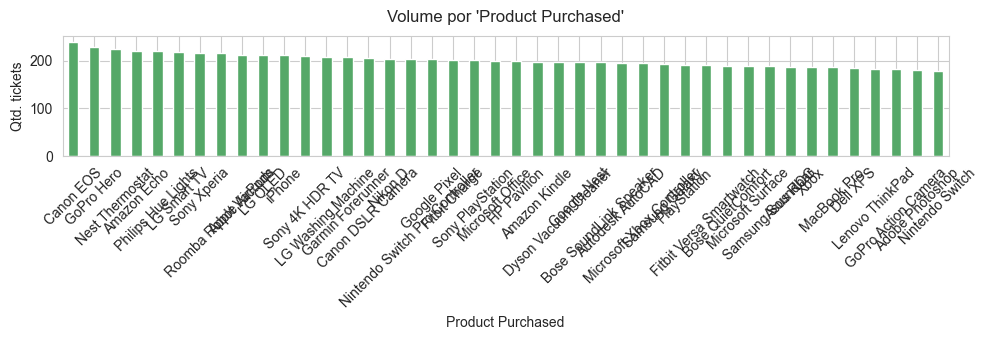

In [8]:
group_candidates = ["Product Purchased", "Ticket Type", "Ticket Channel", "Ticket Subject"]
group_col = next((c for c in group_candidates if c in df.columns), None)

if group_col:
    counts = df[group_col].value_counts()
    fig, ax = plt.subplots(figsize=(10, 3.5))
    counts.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
    ax.set_title(f"Volume por '{group_col}'", fontsize=12, pad=10)
    ax.set_xlabel(group_col)
    ax.set_ylabel("Qtd. tickets")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "docs" / "screenshots" / "01_volume_by_category.png", dpi=150)
    plt.show()
else:
    print("Colunas disponíveis:", df.columns.tolist())

## 9. Salvar relatório de nulos e avançar

In [9]:
proc_path = PROJECT_ROOT / "data" / "processed"
proc_path.mkdir(parents=True, exist_ok=True)

if not null_report.empty:
    null_report.to_csv(proc_path / "null_report.csv")
    print(f"Relatório de nulos salvo em: {proc_path / 'null_report.csv'}")

print()
print("=" * 50)
print("  Notebook 01 concluído.")
print("  Próximo: abra 02_tratamento.ipynb")
print("=" * 50)

Relatório de nulos salvo em: c:\Users\arthu\%USERPROFILE%\Documents\GitHub\kpi-operations-pipeline\data\processed\null_report.csv

  Notebook 01 concluído.
  Próximo: abra 02_tratamento.ipynb
